In [1]:
import os
import sys
import json
import argparse
import torch
import numpy as np
import pickle
import random
import re
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader
import torch.nn as nn

# Add project root to path to allow importing from other directories
sys.path.append("/home/hofmann/Documents/projects/RepresentationLearning/code")

from dra_1.py_datasets import ActivationDataset
from dra_1.inject_noise import inject_isotropic_noise, inject_nonisotropic_noise
from dra_1.model_loader import load_model_for_utility_check
from rep_lr.models import ChannelEstimationHead

In [22]:
def get_empirical_fim(head, data_loader, device, latent_dim):
    """Calculates the empirical Fisher Information Matrix for channel estimation head."""
    fim = torch.zeros((latent_dim, latent_dim), device=device)
    num_samples = 0
    head.to(device).eval()

    # Use the same complex MSE loss as in training for consistency
    mse_loss = nn.MSELoss()
    def complex_mse_loss(pred, target):
        pred_flat = pred.view(pred.size(0), -1)
        target_flat = target.view(target.size(0), -1)
        return mse_loss(pred_flat, target_flat)
    criterion = complex_mse_loss

    for batch in tqdm(data_loader, desc="Calculating FIM"):
        # Unpack based on what ActivationDataset yields in train mode
        _, rf_labels, _, cfo_labels, _, ch_labels, activations, _ = batch

        print(activations.shape)
        
        activations = activations.squeeze(1).to(device)
        activations = activations.view(activations.size(0), -1)
        print(activations.shape)

        print(ch_labels.shape)
        activations.requires_grad = True # Ensure we can get gradients

        head.zero_grad()
        
        # Channel estimation target
        y_target = ch_labels.to(device)
        # Fix channel label shape: [batch, 1, 2, 52] -> [batch, 2, 52]
        if y_target.dim() == 4 and y_target.size(1) == 1:
            y_target = y_target.squeeze(1)

        y_hat = head(activations)
        loss = criterion(y_hat, y_target)
        loss.backward()
        
        if activations.grad is not None:
            J = activations.grad
            fim += J.T @ J
            num_samples += activations.size(0)

    if num_samples == 0:
        return fim
    return fim / num_samples

In [23]:
def evaluate_channel_utility(head, test_dl, device, output_dir, noise_level, L=None, V=None, noise_type='isotropic'):
    """Evaluate channel estimation utility with noise injection."""
    head.to(device).eval()
    all_y_true, all_y_pred, evaluation_results = [], [], []
    
    # Define the same complex MSE loss as used in training
    mse_loss = nn.MSELoss()
    def complex_mse_loss(pred, target):
        pred_flat = pred.view(pred.size(0), -1)
        target_flat = target.view(target.size(0), -1)
        return mse_loss(pred_flat, target_flat)
    
    total_training_loss = 0.0
    num_samples = 0

    with torch.no_grad():
        for _, _, _, _, _, labels, activations, file_paths in tqdm(test_dl, desc="Evaluating Channel Utility"):
            activations = activations.squeeze(1).to(device)
            labels = labels.to(device)
            
            activations = activations.view(activations.size(0), -1)

            if noise_type == 'isotropic':
                noisy_activations = inject_isotropic_noise(activations, noise_level)
            elif noise_type == 'nonisotropic':
                noisy_activations = inject_nonisotropic_noise(activations, noise_level, L, V)
            else:
                noisy_activations = activations
            
            # Reshape back to (batch, 2, dim) for the head
            noisy_activations = noisy_activations.view(noisy_activations.size(0), 2, -1)

            outputs = head(noisy_activations)
            
            # Compute training loss for this batch
            batch_loss = complex_mse_loss(outputs, labels)
            total_training_loss += batch_loss.item() * labels.size(0)
            num_samples += labels.size(0)
            
            for i in range(labels.size(0)):
                true_val = labels[i].cpu().numpy()
                pred_val = outputs[i].cpu().numpy()
                all_y_true.append(true_val)
                all_y_pred.append(pred_val)
                evaluation_results.append({
                    'filename': os.path.basename(file_paths[i]),
                    'y_true': true_val.tolist(), 'y_pred': pred_val.tolist(),
                })

    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)

    # Reshape the arrays to treat the two channels as real and imaginary parts
    # The expected shape for y_true and y_pred is (num_samples, 2, 52)
    # If it comes in as (num_samples, 1, 104), we reshape it.
    if y_true.shape[1] == 1 and y_true.shape[2] == 104:
        y_true = y_true.reshape(y_true.shape[0], 2, 52)
    if y_pred.shape[1] == 1 and y_pred.shape[2] == 104:
        y_pred = y_pred.reshape(y_pred.shape[0], 2, 52)

    if len(y_true.shape) == 4 and y_true.shape[1] == 1:
        y_true = np.squeeze(y_true, axis=1)

    y_true_complex = y_true[:, 0, :] + 1j * y_true[:, 1, :]
    y_pred_complex = y_pred[:, 0, :] + 1j * y_pred[:, 1, :]

    nmse = np.mean(np.abs(y_true_complex - y_pred_complex)**2) / np.mean(np.abs(y_true_complex)**2)
    nmse_db = 10 * np.log10(nmse)
    
    y_true_real = y_true[:, 0, :]
    y_pred_real = y_pred[:, 0, :]
    y_true_imag = y_true[:, 1, :]
    y_pred_imag = y_pred[:, 1, :]

    mae_real = mean_absolute_error(y_true_real, y_pred_real)
    mse_real = mean_squared_error(y_true_real, y_pred_real)
    r2_real = r2_score(y_true_real, y_pred_real)

    mae_imag = mean_absolute_error(y_true_imag, y_pred_imag)
    mse_imag = mean_squared_error(y_true_imag, y_pred_imag)
    r2_imag = r2_score(y_true_imag, y_pred_imag)
    
    # Compute average training loss
    avg_training_loss = total_training_loss / num_samples if num_samples > 0 else 0.0
    
    metrics = {
        'training_loss': float(avg_training_loss),  # Same loss as used in training
        'nmse': float(nmse),
        'nmse_db': float(nmse_db),
        'real_part': {
            'mae': float(mae_real),
            'mse': float(mse_real),
            'r2_score': float(r2_real)
        },
        'imaginary_part': {
            'mae': float(mae_imag),
            'mse': float(mse_imag),
            'r2_score': float(r2_imag)
        }
    }
    
    print("\nChannel Estimation Metrics:")
    print(f"Training Loss: {avg_training_loss:.4f}")  # Same loss as used in training
    print(f"NMSE: {nmse:.4f}")
    print(f"NMSE (dB): {nmse_db:.4f}")
    print("\nReal Part Metrics:")
    for key, value in metrics['real_part'].items():
        print(f"{key.upper()}: {value:.4f}")
    print("\nImaginary Part Metrics:")
    for key, value in metrics['imaginary_part'].items():
        print(f"{key.upper()}: {value:.4f}")

    with open(os.path.join(output_dir, 'channel_metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=4)
    with open(os.path.join(output_dir, 'channel_predictions.json'), 'w') as f:
        json.dump(evaluation_results, f, indent=4)
    print(f"Channel metrics and predictions saved in {output_dir}")

In [24]:
def run_channel_evaluations(cli_args, head, test_dl, train_files, activation_dir):
    """Run channel estimation evaluations for all noise levels and types."""
    device = torch.device(f'cuda:{cli_args.gpu_id}' if torch.cuda.is_available() else 'cpu')
    noise_levels = np.linspace(0, 10, 4)  # 0, 1, 2, ..., 10
    noise_types = ['isotropic', 'nonisotropic']

    # --- Pre-calculate FIM for non-isotropic noise ---
    L, V = None, None
    if 'nonisotropic' in noise_types:
        print("\n===== Pre-calculating FIM for Anisotropic Noise =====")
        if not train_files:
            raise ValueError("Training files are required for FIM calculation but not found in partition.")
        
        # Use a subset of training data for FIM
        random.shuffle(train_files)
        fim_files = train_files[:cli_args.fim_samples]
        fim_dataset = ActivationDataset(activation_dir=activation_dir, file_list=fim_files, test_mode=False)
        fim_dl = DataLoader(fim_dataset, batch_size=cli_args.batch_size, shuffle=True)
        
        latent_dim = head.input_dim
        print(f"Calculating FIM for channel estimation head (latent_dim: {latent_dim})")
        fim = get_empirical_fim(head, fim_dl, device, latent_dim)
        
        print("Performing eigendecomposition of FIM...")
        L_e, V = torch.linalg.eigh(fim)
        #take absolute value of eigenvalues
        L = torch.abs(L_e)
        #L = torch.relu(L_e)  # Ensure non-negative eigenvalues
        print("FIM calculation and decomposition complete.")

    # --- Run evaluation loop ---
    results_r2 = {'isotropic': [], 'nonisotropic': []}
    results_mse = {'isotropic': [], 'nonisotropic': []}
    
    for noise_type in noise_types:
        for noise_level in tqdm(noise_levels, desc=f"Evaluating {noise_type} noise"):
            
            # Skip FIM-based evaluation if data is not available
            if noise_type == 'nonisotropic' and L is None:
                continue

            # Determine the final output directory path
            base_output_dir = cli_args.output_dir
            if base_output_dir is None:
                base_output_dir = os.path.join(cli_args.experiment_path, 'channel_debug_exps')
            
            noise_level_str = f"level_{str(noise_level).replace('.', '_')}"
            output_dir = os.path.join(base_output_dir, noise_type, noise_level_str)
            os.makedirs(output_dir, exist_ok=True)
            
            print(f"\n===== Evaluating Channel Estimation (Noise: {noise_type}, Level: {noise_level}) =====")
            print(f"Saving results to: {output_dir}")
            
            evaluate_channel_utility(head, test_dl, device, output_dir, noise_level, L, V, noise_type)
            
            # Collect results for plotting
            metrics_file = os.path.join(output_dir, 'channel_metrics.json')
            if os.path.exists(metrics_file):
                with open(metrics_file, 'r') as f:
                    metrics = json.load(f)
                    # Average the R² and MSE of real and imaginary parts
                    r2_metric = (metrics['real_part']['r2_score'] + metrics['imaginary_part']['r2_score']) / 2.0
                    mse_metric = (metrics['real_part']['mse'] + metrics['imaginary_part']['mse']) / 2.0
                    results_r2[noise_type].append(r2_metric)
                    results_mse[noise_type].append(mse_metric)
    
    print("\nChannel estimation evaluations complete.")
    return base_output_dir, results_r2, results_mse

In [25]:
def plot_channel_results(base_output_dir, results_r2, results_mse):
    """Plot channel estimation results."""
    print("\n--- Generating channel estimation plots ---")
    noise_levels = np.linspace(0, 10, 11)
    
    plt.style.use('seaborn-v0_8-darkgrid')
    colors = plt.cm.get_cmap('viridis', 4)

    # Plot R² scores
    plt.figure(figsize=(12, 7))
    plt.plot(noise_levels, results_r2['isotropic'], 'o-', color=colors(0.3), linewidth=2, markersize=8, label='Isotropic Noise')
    plt.plot(noise_levels, results_r2['nonisotropic'], 's--', color=colors(0.7), linewidth=2, markersize=8, label='Non-isotropic Noise')

    plt.title('Channel Estimation R² Score vs Noise Level', fontsize=16, fontweight='bold')
    plt.xlabel('Noise Level', fontsize=14)
    plt.ylabel('R² Score', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    plot_path = os.path.join(base_output_dir, 'channel_estimation_r2_vs_noise.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved R² plot: {plot_path}")
    plt.close()

    # Plot MSE scores
    plt.figure(figsize=(12, 7))
    plt.plot(noise_levels, results_mse['isotropic'], 'o-', color=colors(0.3), linewidth=2, markersize=8, label='Isotropic Noise')
    plt.plot(noise_levels, results_mse['nonisotropic'], 's--', color=colors(0.7), linewidth=2, markersize=8, label='Non-isotropic Noise')

    plt.title('Channel Estimation MSE vs Noise Level', fontsize=16, fontweight='bold')
    plt.xlabel('Noise Level', fontsize=14)
    plt.ylabel('MSE', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    plot_path = os.path.join(base_output_dir, 'channel_estimation_mse_vs_noise.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved MSE plot: {plot_path}")
    plt.close()

    # Save aggregated results to JSON
    aggregated_results = {
        'noise_levels': noise_levels.tolist(),
        'r2_scores': results_r2,
        'mse_scores': results_mse
    }
    
    results_json_path = os.path.join(base_output_dir, 'channel_estimation_results.json')
    with open(results_json_path, 'w') as f:
        json.dump(aggregated_results, f, indent=4)
    print(f"Saved aggregated results to: {results_json_path}")

In [26]:
experiment_path = "/home/hofmann/Documents/projects/RepresentationLearning/results_20250720_172807/rf_cfo_channel/rf_fingerprinting_cfo_estimation_channel_estimation_20250720_172811"
output_dir = None 
fim_samples = 10000
gpu_id = 0
batch_size = 256
skip_eval = False

device = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_data = load_model_for_utility_check(experiment_path, device)
model = model_data['model']
train_args = model_data['train_args']
is_mtl = model_data['is_mtl']

# Get channel estimation head
if is_mtl:
    if 'channel_estimation' not in model['heads']:
        raise ValueError("Channel estimation head not found in MTL model")
    head = model['heads']['channel_estimation']
else:
    if train_args.task != 'channel_estimation':
        raise ValueError("Model is not trained for channel estimation task")
    head = model['head']

print(f"Channel estimation head loaded. Input dim: {head.input_dim}")

activation_dir = os.path.join(experiment_path, 'activations')
partition_file = train_args.pkl_dataset_path



with open(partition_file, 'rb') as handle:
    content = pickle.load(handle)
train_files = content.get('train')
test_files = content.get('test')

test_dataset = ActivationDataset(activation_dir=activation_dir, file_list=test_files, test_mode=True)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)






Using device: cuda:0
Loading model from: /home/hofmann/Documents/projects/RepresentationLearning/results_20250720_172807/rf_cfo_channel/rf_fingerprinting_cfo_estimation_channel_estimation_20250720_172811/rf_fingerprinting_cfo_estimation_channel_estimation_best.pt
Loading MTL model architecture...
Channel estimation head loaded. Input dim: 512
Initialized dataset with 26180 files. Found and mapped 26180 activations.


In [27]:
#try to emulate cli args 
cli_args = argparse.Namespace()
cli_args.output_dir = None
cli_args.fim_samples = fim_samples
cli_args.batch_size = batch_size
cli_args.skip_eval = skip_eval
cli_args.experiment_path = experiment_path
cli_args.gpu_id = gpu_id


random.shuffle(train_files)
fim_files = train_files[:cli_args.fim_samples]
fim_dataset = ActivationDataset(activation_dir=activation_dir, file_list=fim_files, test_mode=False)
print(len(fim_dataset))
fim_dl = DataLoader(fim_dataset, batch_size=cli_args.batch_size, shuffle=True)

latent_dim = head.input_dim
print(f"Calculating FIM for channel estimation head (latent_dim: {latent_dim})")
fim = get_empirical_fim(head, fim_dl, device, latent_dim)

print("Performing eigendecomposition of FIM...")
L_e, V = torch.linalg.eigh(fim)
#take absolute value of eigenvalues

Initialized dataset with 10000 files. Found and mapped 10000 activations.
10000
Calculating FIM for channel estimation head (latent_dim: 512)


Calculating FIM:   5%|▌         | 2/40 [00:00<00:07,  5.17it/s]

torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])
torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])


Calculating FIM:  10%|█         | 4/40 [00:00<00:06,  5.46it/s]

torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])
torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])


...

torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])
torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])


Calculating FIM:  60%|██████    | 24/40 [00:04<00:02,  5.39it/s]

torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])
torch.Size([256, 1, 2, 256])
torch.Size([256, 512])
torch.Size([256, 1, 2, 52])


Calculating FIM:  60%|██████    | 24/40 [00:04<00:03,  5.26it/s]


KeyboardInterrupt: 

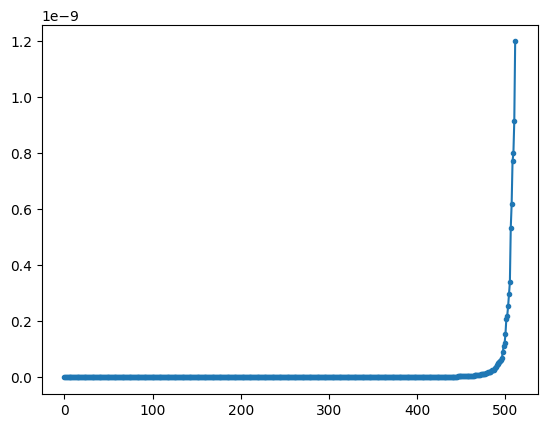

In [15]:
import matplotlib.pyplot as plt

plt.plot(L_e.detach().cpu().numpy(),'.-')
plt.show()

In [16]:






base_output_dir, results_r2, results_mse = run_channel_evaluations(cli_args, head, test_dl, train_files, activation_dir)


===== Pre-calculating FIM for Anisotropic Noise =====
Initialized dataset with 10000 files. Found and mapped 10000 activations.
Calculating FIM for channel estimation head (latent_dim: 512)


Calculating FIM: 100%|██████████| 40/40 [00:06<00:00,  5.90it/s]


Performing eigendecomposition of FIM...
FIM calculation and decomposition complete.


Evaluating isotropic noise:   0%|          | 0/4 [00:00<?, ?it/s]


===== Evaluating Channel Estimation (Noise: isotropic, Level: 0.0) =====
Saving results to: /home/hofmann/Documents/projects/RepresentationLearning/results_20250720_172807/rf_cfo_channel/rf_fingerprinting_cfo_estimation_channel_estimation_20250720_172811/channel_debug_exps/isotropic/level_0_0


...

Channel metrics and predictions saved in /home/hofmann/Documents/projects/RepresentationLearning/results_20250720_172807/rf_cfo_channel/rf_fingerprinting_cfo_estimation_channel_estimation_20250720_172811/channel_debug_exps/nonisotropic/level_6_666666666666667

===== Evaluating Channel Estimation (Noise: nonisotropic, Level: 10.0) =====
Saving results to: /home/hofmann/Documents/projects/RepresentationLearning/results_20250720_172807/rf_cfo_channel/rf_fingerprinting_cfo_estimation_channel_estimation_20250720_172811/channel_debug_exps/nonisotropic/level_10_0


Evaluating Channel Utility: 100%|██████████| 103/103 [00:05<00:00, 18.54it/s]



Channel Estimation Metrics:
Training Loss: 0.3960
NMSE: 0.7920
NMSE (dB): -1.0127

Real Part Metrics:
MAE: 0.5092
MSE: 0.3981
R2_SCORE: 0.2009

Imaginary Part Metrics:
MAE: 0.5069
MSE: 0.3939
R2_SCORE: 0.2082


Evaluating nonisotropic noise: 100%|██████████| 4/4 [00:41<00:00, 10.46s/it]

Channel metrics and predictions saved in /home/hofmann/Documents/projects/RepresentationLearning/results_20250720_172807/rf_cfo_channel/rf_fingerprinting_cfo_estimation_channel_estimation_20250720_172811/channel_debug_exps/nonisotropic/level_10_0

Channel estimation evaluations complete.


In [12]:
base_output_dir = os.path.join(experiment_path, 'channel_debug_exps')
# Load existing results if available
results_json_path = os.path.join(base_output_dir, 'channel_estimation_results.json')
if os.path.exists(results_json_path):
    with open(results_json_path, 'r') as f:
        aggregated_results = json.load(f)
        results_r2 = aggregated_results['r2_scores']
        results_mse = aggregated_results['mse_scores']
else:
    print("No existing results found. Please run without --skip_eval first.")
    

No existing results found. Please run without --skip_eval first.


In [36]:
# Load all three heads and compute FIMs
def compute_fim_for_all_tasks(model_data, fim_dl, device):
    """Compute FIM for all available tasks."""
    heads = model_data['model']['heads'] if 'heads' in model_data['model'] else {model_data['train_args'].task: model_data['model']['head']}
    
    fims = {}
    eigendata = {}
    
    for task_name, head in heads.items():
        print(f"\nCalculating FIM for {task_name}...")
        latent_dim = head.input_dim
        
        # Calculate FIM
        fim = torch.zeros((latent_dim, latent_dim), device=device)
        num_samples = 0
        head.to(device).eval()
        
        # Define appropriate loss function
        if task_name == 'rf_fingerprinting':
            criterion = nn.CrossEntropyLoss()
        else:
            mse_loss = nn.MSELoss()
            def complex_mse_loss(pred, target):
                pred_flat = pred.view(pred.size(0), -1)
                target_flat = target.view(target.size(0), -1)
                return mse_loss(pred_flat, target_flat)
            criterion = complex_mse_loss
        
        for batch in tqdm(fim_dl, desc=f"Calculating FIM for {task_name}", leave=False):
            _, rf_labels, _, cfo_labels, _, ch_labels, activations, _ = batch
            
            activations_squeezed = activations.squeeze(1).to(device)
            original_shape = activations_squeezed.shape
            
            activations_flat = activations_squeezed.view(activations_squeezed.size(0), -1)
            activations_flat.requires_grad = True
            
            head.zero_grad()
            
            # Select appropriate target based on task
            if task_name == 'rf_fingerprinting':
                y_target = rf_labels.to(device)
                if y_target.dim() > 1:
                    y_target = y_target.view(-1)
                # Reshape activations for RF head
                activations_for_head = activations_flat.view(original_shape)
            elif task_name == 'cfo_estimation':
                y_target = cfo_labels.to(device).float()
                if y_target.dim() > 1:
                    y_target = y_target.view(-1)
                # Reshape activations for CFO head
                activations_for_head = activations_flat.view(original_shape)
            elif task_name == 'channel_estimation':
                y_target = ch_labels.to(device)
                if y_target.dim() == 4 and y_target.size(1) == 1:
                    y_target = y_target.squeeze(1)
                # Channel head expects flattened input
                activations_for_head = activations_flat
            else:
                continue
                
            y_hat = head(activations_for_head)
            if y_hat.dim() > 1 and y_target.dim() == 1 and task_name != 'rf_fingerprinting':
                y_hat = y_hat.squeeze(-1)
            
            loss = criterion(y_hat, y_target)
            loss.backward()
            
            if activations_flat.grad is not None:
                J = activations_flat.grad
                fim += J.T @ J
                num_samples += activations_flat.size(0)
        
        if num_samples > 0:
            fim = fim / num_samples

        trace_fim = torch.trace(fim)
        if trace_fim > 1e-10:
            fim = fim / trace_fim
            print(f"  FIM for {task_name} normalized by its trace: {trace_fim:.3e}")
        else:
            print(f"  Warning: FIM for {task_name} has a zero or near-zero trace. Skipping normalization.")
        
        L_e, V = torch.linalg.eigh(fim)
        L = torch.abs(L_e)  # Use absolute values
        print(L)
        
        fims[task_name] = fim
        eigendata[task_name] = {'eigenvalues': L, 'eigenvectors': V}
        
        print(f"FIM calculation complete for {task_name}. Shape: {fim.shape}")
    
    return fims, eigendata

# Compute FIMs for all tasks
print("Computing FIMs for all available tasks...")
all_fims, all_eigendata = compute_fim_for_all_tasks(model_data, fim_dl, device)


Computing FIMs for all available tasks...

Calculating FIM for rf_fingerprinting...


Calculating FIM for rf_fingerprinting:   0%|          | 0/40 [00:00<?, ?it/s]

  FIM for rf_fingerprinting normalized by its trace: 4.880e-06
tensor([1.9506e-08, 1.2616e-08, 1.0709e-08, 1.0121e-08, 9.2660e-09, 9.1632e-09,
        7.8869e-09, 7.6391e-09, 6.2328e-09, 5.5286e-09, 4.2665e-09, 4.0996e-09,
        3.5775e-09, 3.5401e-09, 2.9546e-09, 2.7934e-09, 2.5503e-09, 2.3825e-09,
        2.2207e-09, 2.1913e-09, 2.1865e-09, 2.0896e-09, 2.0745e-09, 1.8368e-09,
        1.7328e-09, 1.6357e-09, 1.4521e-09, 1.4130e-09, 1.2955e-09, 1.2714e-09,
        1.2532e-09, 1.2490e-09, 1.1165e-09, 1.0348e-09, 1.0091e-09, 1.0069e-09,
        9.7655e-10, 9.7424e-10, 9.7012e-10, 9.4695e-10, 9.3396e-10, 9.1908e-10,
        8.6970e-10, 8.5172e-10, 8.2330e-10, 8.1916e-10, 8.1727e-10, 8.0967e-10,
        8.0110e-10, 7.9637e-10, 7.6420e-10, 7.6111e-10, 7.5045e-10, 7.5018e-10,
        7.3847e-10, 7.3456e-10, 7.3309e-10, 7.2749e-10, 7.2495e-10, 7.2463e-10,
        7.1711e-10, 7.1393e-10, 7.0915e-10, 6.7085e-10, 6.6866e-10, 6.4950e-10,
        6.3878e-10, 6.3514e-10, 6.2050e-10, 6.1143e-10, 6

  FIM for cfo_estimation normalized by its trace: 1.719e-05
tensor([6.7645e-08, 4.4073e-08, 3.8764e-08, 6.8758e-09, 6.3286e-09, 3.1505e-09,
        2.3987e-09, 1.8818e-09, 1.5348e-09, 1.5069e-09, 1.3922e-09, 1.2685e-09,
        1.1572e-09, 1.1253e-09, 1.0261e-09, 1.0233e-09, 1.0074e-09, 9.8134e-10,
        9.7472e-10, 9.6168e-10, 9.6051e-10, 9.6040e-10, 9.1550e-10, 9.1485e-10,
        8.4816e-10, 8.4353e-10, 8.4083e-10, 8.3778e-10, 8.2146e-10, 8.2145e-10,
        8.1607e-10, 8.0309e-10, 7.9490e-10, 7.6478e-10, 7.6037e-10, 7.5657e-10,
        7.5209e-10, 7.4281e-10, 7.4152e-10, 7.3777e-10, 7.1773e-10, 7.1031e-10,
        7.0426e-10, 6.9211e-10, 6.9151e-10, 6.9128e-10, 6.7043e-10, 6.6566e-10,
        6.6054e-10, 6.5967e-10, 6.5784e-10, 6.5085e-10, 6.2897e-10, 6.0669e-10,
        6.0526e-10, 6.0107e-10, 5.8715e-10, 5.6539e-10, 5.6278e-10, 5.4659e-10,
        5.3128e-10, 5.2703e-10, 5.1285e-10, 5.1195e-10, 5.1103e-10, 4.9529e-10,
        4.9311e-10, 4.7285e-10, 4.6989e-10, 4.3789e-10, 4.35

  FIM for channel_estimation normalized by its trace: 7.726e-09
tensor([3.4382e-08, 2.0102e-08, 1.6633e-08, 1.3578e-08, 1.1304e-08, 1.0581e-08,
        8.6724e-09, 8.1196e-09, 5.8587e-09, 5.3863e-09, 4.9103e-09, 3.1794e-09,
        2.8313e-09, 2.2817e-09, 2.2374e-09, 2.1614e-09, 2.1175e-09, 2.0426e-09,
        1.9722e-09, 1.8413e-09, 1.8078e-09, 1.6111e-09, 1.5161e-09, 1.3576e-09,
        1.2285e-09, 1.1428e-09, 1.0067e-09, 9.8248e-10, 9.6581e-10, 9.5257e-10,
        9.3856e-10, 9.0863e-10, 8.9983e-10, 8.4564e-10, 8.2809e-10, 7.8003e-10,
        7.7931e-10, 7.4801e-10, 7.1475e-10, 7.0132e-10, 6.9898e-10, 6.9598e-10,
        6.9289e-10, 6.9119e-10, 6.7236e-10, 6.6138e-10, 6.5518e-10, 6.3264e-10,
        6.2256e-10, 6.0660e-10, 6.0007e-10, 5.9078e-10, 5.8789e-10, 5.7667e-10,
        5.6931e-10, 5.5105e-10, 5.4654e-10, 5.4472e-10, 5.4127e-10, 5.1663e-10,
        5.1506e-10, 5.0710e-10, 5.0208e-10, 4.9443e-10, 4.9145e-10, 4.8532e-10,
        4.8159e-10, 4.6839e-10, 4.6144e-10, 4.5875e-10, 

Global maximum dot product across all task pairs: 0.352


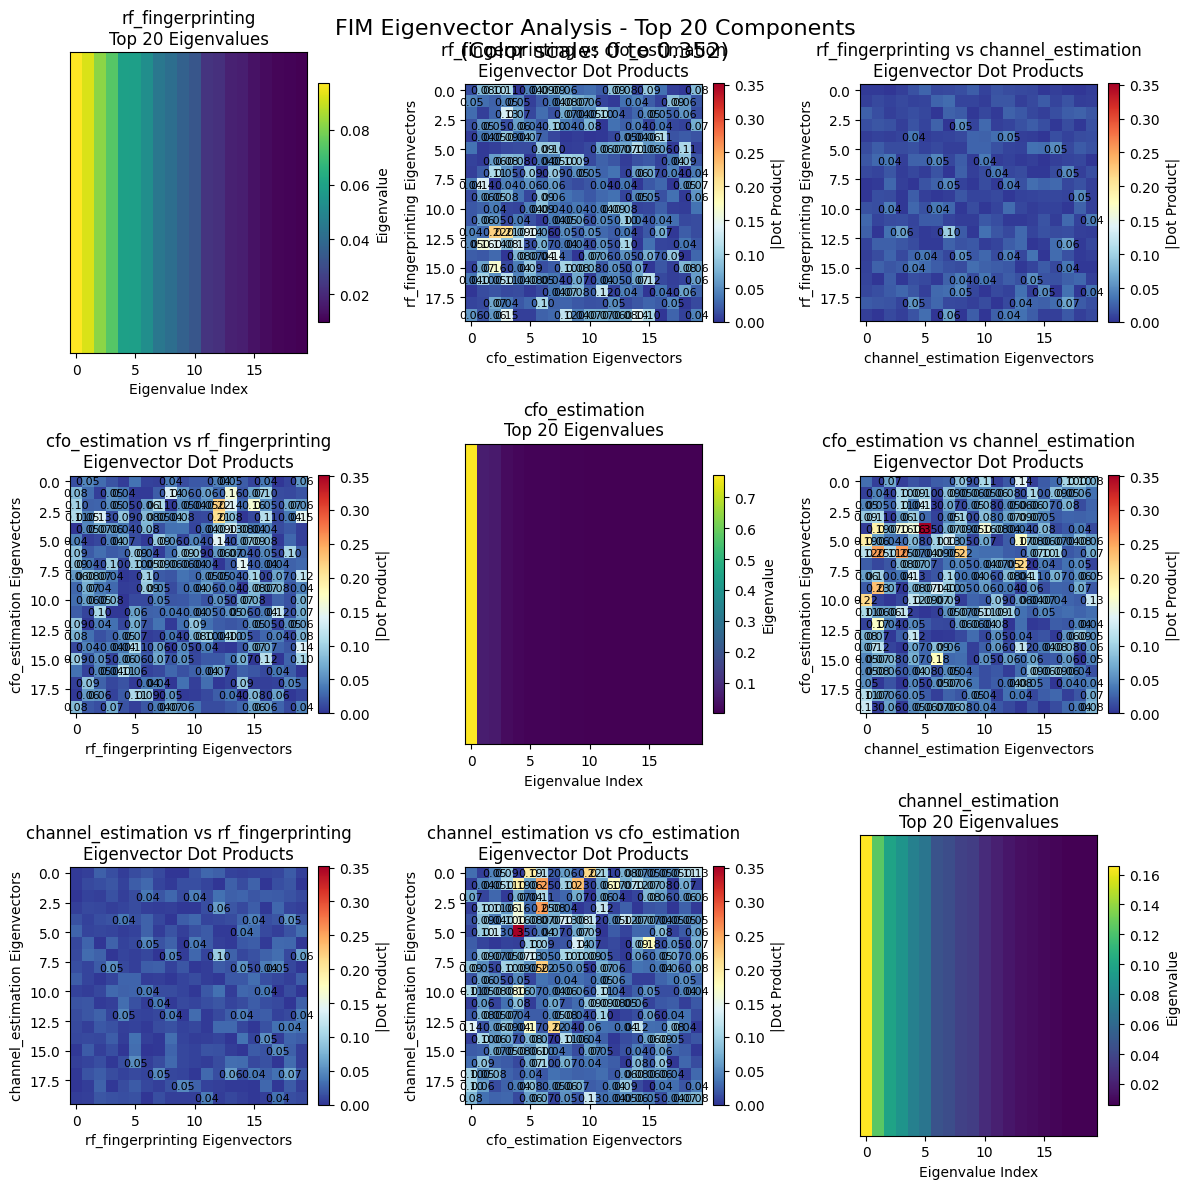

\nSummary of eigenvector overlaps (top 20 components):
rf_fingerprinting vs cfo_estimation:
  Max overlap: 0.221
  Mean overlap: 0.042
  High overlaps (>0.5): 0/400

rf_fingerprinting vs channel_estimation:
  Max overlap: 0.096
  Mean overlap: 0.016
  High overlaps (>0.5): 0/400

cfo_estimation vs channel_estimation:
  Max overlap: 0.352
  Mean overlap: 0.052
  High overlaps (>0.5): 0/400



In [37]:
# Function to create dot product matrix heatmaps
def plot_eigenvector_dot_products(all_eigendata, n_top=10):
    """
    Plot heatmaps showing dot products between top eigenvectors of different tasks.
    This shows how intertwined the privacy-preserving directions are.
    """
    task_names = list(all_eigendata.keys())
    n_tasks = len(task_names)
    
    # First pass: compute all dot product matrices to find global max
    all_dot_matrices = {}
    global_max_dot = 0
    
    for i, task1 in enumerate(task_names):
        for j, task2 in enumerate(task_names):
            if i != j:  # Only off-diagonal elements
                V1 = all_eigendata[task1]['eigenvectors'].cpu().numpy()
                V2 = all_eigendata[task2]['eigenvectors'].cpu().numpy()
                eigenvals1 = all_eigendata[task1]['eigenvalues'].cpu().numpy()
                eigenvals2 = all_eigendata[task2]['eigenvalues'].cpu().numpy()
                
                # Sort by eigenvalues (descending) and get top eigenvectors
                idx1 = np.argsort(eigenvals1)[::-1][:n_top]
                idx2 = np.argsort(eigenvals2)[::-1][:n_top]
                
                top_V1 = V1[:, idx1]  # [latent_dim, n_top]
                top_V2 = V2[:, idx2]  # [latent_dim, n_top]
                
                # Compute dot product matrix
                dot_matrix = np.abs(top_V1.T @ top_V2)  # [n_top, n_top]
                all_dot_matrices[(task1, task2)] = dot_matrix
                
                # Update global maximum
                current_max = np.max(dot_matrix)
                global_max_dot = max(global_max_dot, current_max)
    
    print(f"Global maximum dot product across all task pairs: {global_max_dot:.3f}")
    
    # Create figure with subplots for each pair of tasks
    fig, axes = plt.subplots(n_tasks, n_tasks, figsize=(4*n_tasks, 4*n_tasks))
    
    # Handle case where there's only one task
    if n_tasks == 1:
        axes = np.array([[axes]])
    elif n_tasks == 2:
        axes = axes.reshape(2, 2)
    
    for i, task1 in enumerate(task_names):
        for j, task2 in enumerate(task_names):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: show eigenvalue spectrum
                eigenvals = all_eigendata[task1]['eigenvalues'].cpu().numpy()
                # Sort eigenvalues in descending order and take top n_top
                sorted_eigenvals = np.sort(eigenvals)[::-1][:n_top]
                
                im = ax.imshow(sorted_eigenvals.reshape(1, -1), aspect='auto', cmap='viridis')
                ax.set_title(f'{task1}\nTop {n_top} Eigenvalues')
                ax.set_xlabel('Eigenvalue Index')
                ax.set_ylabel('')
                ax.set_yticks([])
                
                # Add colorbar
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                cbar.set_label('Eigenvalue')
                
            else:
                # Off-diagonal: use pre-computed dot product matrix
                dot_matrix = all_dot_matrices[(task1, task2)]
                
                # Plot heatmap with global max as vmax
                im = ax.imshow(dot_matrix, cmap='RdYlBu_r', vmin=0, vmax=global_max_dot)
                ax.set_title(f'{task1} vs {task2}\nEigenvector Dot Products')
                ax.set_xlabel(f'{task2} Eigenvectors')
                ax.set_ylabel(f'{task1} Eigenvectors')
                
                # Add colorbar
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                cbar.set_label('|Dot Product|')
                
                # Add text annotations for values (adjust threshold based on global max)
                annotation_threshold = global_max_dot * 0.1  # Show values above 10% of global max
                for ii in range(n_top):
                    for jj in range(n_top):
                        if dot_matrix[ii, jj] > annotation_threshold:
                            text = ax.text(jj, ii, f'{dot_matrix[ii, jj]:.2f}',
                                         ha="center", va="center", color="black", fontsize=8)
    
    plt.tight_layout()
    plt.suptitle(f'FIM Eigenvector Analysis - Top {n_top} Components\n(Color scale: 0 to {global_max_dot:.3f})', fontsize=16, y=0.98)
    plt.show()
    
    # Print summary statistics
    print(f"\\nSummary of eigenvector overlaps (top {n_top} components):")
    print("="*60)
    
    for i, task1 in enumerate(task_names):
        for j, task2 in enumerate(task_names):
            if i < j:  # Only compute for upper triangle
                V1 = all_eigendata[task1]['eigenvectors'].cpu().numpy()
                V2 = all_eigendata[task2]['eigenvectors'].cpu().numpy()
                eigenvals1 = all_eigendata[task1]['eigenvalues'].cpu().numpy()
                eigenvals2 = all_eigendata[task2]['eigenvalues'].cpu().numpy()
                
                # Get top eigenvectors
                idx1 = np.argsort(eigenvals1)[::-1][:n_top]
                idx2 = np.argsort(eigenvals2)[::-1][:n_top]
                
                top_V1 = V1[:, idx1]
                top_V2 = V2[:, idx2]
                
                dot_matrix = np.abs(top_V1.T @ top_V2)
                
                max_overlap = np.max(dot_matrix)
                mean_overlap = np.mean(dot_matrix)
                
                print(f"{task1} vs {task2}:")
                print(f"  Max overlap: {max_overlap:.3f}")
                print(f"  Mean overlap: {mean_overlap:.3f}")
                print(f"  High overlaps (>0.5): {np.sum(dot_matrix > 0.5)}/{n_top*n_top}")
                print()

# Plot the eigenvector analysis
plot_eigenvector_dot_products(all_eigendata, n_top=20)


Maximum absolute correlation (off-diagonal): 0.972


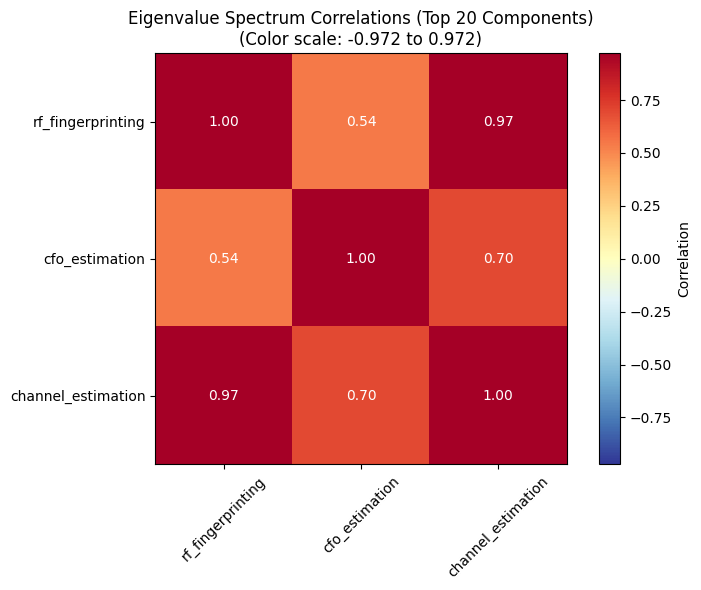

\nEigenvalue spectrum correlations (top 20 components):
rf_fingerprinting vs cfo_estimation: 0.541
rf_fingerprinting vs channel_estimation: 0.972
cfo_estimation vs channel_estimation: 0.698


In [38]:
# Additional analysis: Compute pairwise correlations between FIM eigenvalue spectra
def analyze_eigenvalue_correlations(all_eigendata, n_top=50):
    """
    Analyze correlations between eigenvalue spectra of different tasks.
    This can reveal if tasks have similar importance patterns in the latent space.
    """
    task_names = list(all_eigendata.keys())
    n_tasks = len(task_names)
    
    # Extract top eigenvalues for each task
    eigenvalue_matrix = []
    for task in task_names:
        eigenvals = all_eigendata[task]['eigenvalues'].cpu().numpy()
        # Sort in descending order and take top n_top
        sorted_eigenvals = np.sort(eigenvals)[::-1][:n_top]
        eigenvalue_matrix.append(sorted_eigenvals)
    
    eigenvalue_matrix = np.array(eigenvalue_matrix)  # [n_tasks, n_top]
    
    # Compute correlation matrix
    correlation_matrix = np.corrcoef(eigenvalue_matrix)
    
    # Find the maximum absolute correlation (excluding diagonal which is always 1)
    off_diagonal_mask = ~np.eye(n_tasks, dtype=bool)
    max_abs_corr = np.max(np.abs(correlation_matrix[off_diagonal_mask]))
    
    print(f"Maximum absolute correlation (off-diagonal): {max_abs_corr:.3f}")
    
    # Plot correlation heatmap with dynamic color scale
    plt.figure(figsize=(8, 6))
    vmax = max(max_abs_corr, 0.5)  # Ensure minimum range for visibility
    im = plt.imshow(correlation_matrix, cmap='RdYlBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, label='Correlation')
    
    # Add labels
    plt.xticks(range(n_tasks), task_names, rotation=45)
    plt.yticks(range(n_tasks), task_names)
    plt.title(f'Eigenvalue Spectrum Correlations (Top {n_top} Components)\n(Color scale: -{vmax:.3f} to {vmax:.3f})')
    
    # Add text annotations
    for i in range(n_tasks):
        for j in range(n_tasks):
            text = plt.text(j, i, f'{correlation_matrix[i, j]:.2f}',
                           ha="center", va="center", 
                           color="white" if abs(correlation_matrix[i, j]) > vmax*0.5 else "black")
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation statistics
    print(f"\\nEigenvalue spectrum correlations (top {n_top} components):")
    print("="*50)
    for i, task1 in enumerate(task_names):
        for j, task2 in enumerate(task_names):
            if i < j:
                corr = correlation_matrix[i, j]
                print(f"{task1} vs {task2}: {corr:.3f}")

# Run eigenvalue correlation analysis
analyze_eigenvalue_correlations(all_eigendata, n_top=20)


Running comprehensive FIM norm analysis...
Fisher Information Matrix Norm Analysis

rf_fingerprinting:
  Frobenius norm:     2.212e-01
  Spectral norm:      9.700e-02
  Nuclear norm:       1.000e+00
  Max norm:           4.075e-03
  Trace:              1.000e+00
  L1 norm:            8.734e+01
  Condition number:   9.080e+08
  Effective rank:     485

cfo_estimation:
  Frobenius norm:     7.778e-01
  Spectral norm:      7.725e-01
  Nuclear norm:       1.000e+00
  Max norm:           1.510e-02
  Trace:              1.000e+00
  L1 norm:            2.629e+02
  Condition number:   7.569e+09
  Effective rank:     487

channel_estimation:
  Frobenius norm:     2.821e-01
  Spectral norm:      1.656e-01
  Nuclear norm:       1.000e+00
  Max norm:           6.311e-03
  Trace:              1.000e+00
  L1 norm:            1.090e+02
  Condition number:   1.653e+09
  Effective rank:     466


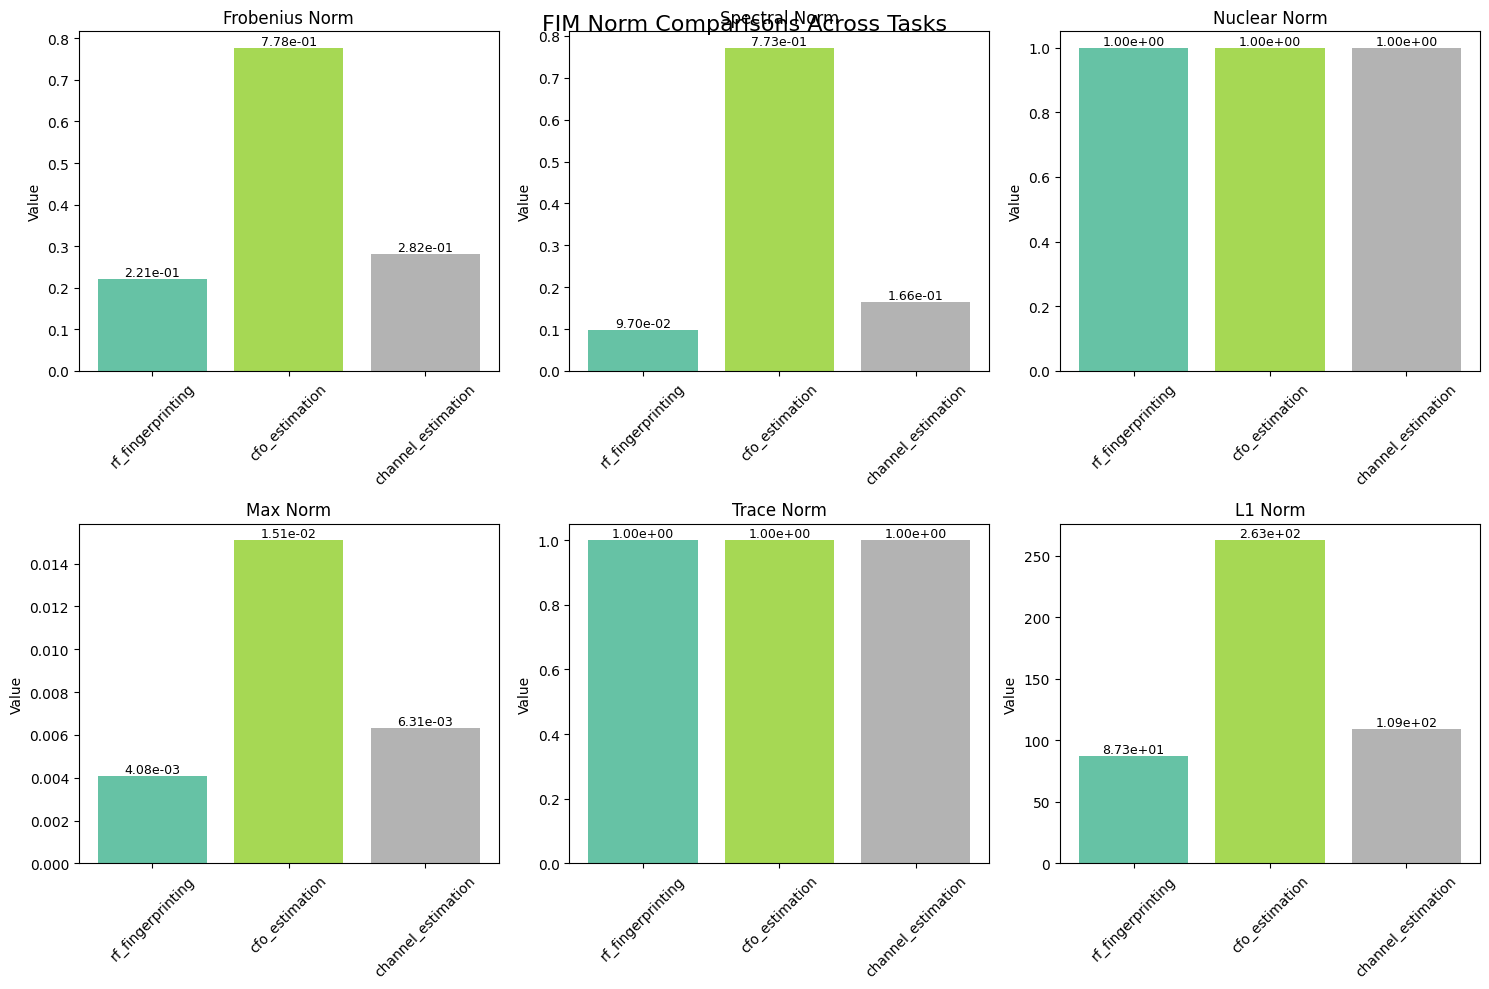

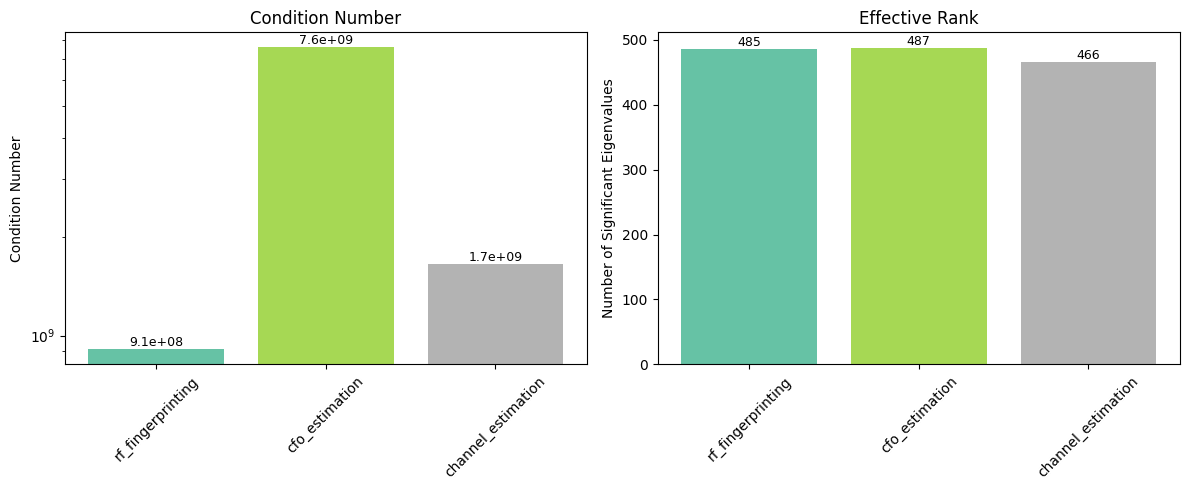


Norm Ratio Analysis
(Ratios help understand matrix structure and concentration)

rf_fingerprinting:
  Spectral/Frobenius: 0.438 (lower = more distributed eigenvalues)
  Nuclear/Spectral:   10.311 (higher = more balanced eigenvalues)
  Frobenius/Nuclear:  0.221
  Max/Frobenius:      0.018 (lower = more distributed elements)

cfo_estimation:
  Spectral/Frobenius: 0.993 (lower = more distributed eigenvalues)
  Nuclear/Spectral:   1.295 (higher = more balanced eigenvalues)
  Frobenius/Nuclear:  0.778
  Max/Frobenius:      0.019 (lower = more distributed elements)

channel_estimation:
  Spectral/Frobenius: 0.587 (lower = more distributed eigenvalues)
  Nuclear/Spectral:   6.039 (higher = more balanced eigenvalues)
  Frobenius/Nuclear:  0.282
  Max/Frobenius:      0.022 (lower = more distributed elements)


In [39]:
# Comprehensive FIM norm analysis
def analyze_fim_norms(all_fims, all_eigendata):
    """
    Compare different matrix norms of Fisher Information Matrices.
    This reveals the relative 'strength' and characteristics of each task's FIM.
    """
    task_names = list(all_fims.keys())
    
    # Dictionary to store all norm values
    norm_results = {}
    
    print("Fisher Information Matrix Norm Analysis")
    print("=" * 60)
    
    for task_name in task_names:
        fim = all_fims[task_name].cpu().numpy()
        eigenvals = all_eigendata[task_name]['eigenvalues'].cpu().numpy()
        
        # Compute various norms
        norms = {}
        
        # 1. Frobenius norm (sum of squares of all elements)
        norms['frobenius'] = np.linalg.norm(fim, ord='fro')
        
        # 2. Spectral norm (largest singular value = largest eigenvalue for positive semidefinite)
        norms['spectral'] = np.linalg.norm(fim, ord=2)
        
        # 3. Nuclear norm (sum of singular values = sum of eigenvalues for positive semidefinite)
        norms['nuclear'] = np.sum(eigenvals)
        
        # 4. Max norm (largest absolute element)
        norms['max'] = np.max(np.abs(fim))
        
        # 5. Trace (sum of diagonal elements = sum of eigenvalues)
        norms['trace'] = np.trace(fim)
        
        # 6. Condition number (ratio of largest to smallest non-zero eigenvalue)
        nonzero_eigenvals = eigenvals[eigenvals > 1e-10]
        if len(nonzero_eigenvals) > 1:
            norms['condition_number'] = np.max(nonzero_eigenvals) / np.min(nonzero_eigenvals)
        else:
            norms['condition_number'] = np.inf
        
        # 7. Effective rank (number of eigenvalues above threshold)
        norms['effective_rank'] = np.sum(eigenvals > 1e-10)
        
        # 8. L1 norm (sum of absolute values)
        norms['l1'] = np.sum(np.abs(fim))
        
        norm_results[task_name] = norms
        
        print(f"\n{task_name}:")
        print(f"  Frobenius norm:     {norms['frobenius']:.3e}")
        print(f"  Spectral norm:      {norms['spectral']:.3e}")
        print(f"  Nuclear norm:       {norms['nuclear']:.3e}")
        print(f"  Max norm:           {norms['max']:.3e}")
        print(f"  Trace:              {norms['trace']:.3e}")
        print(f"  L1 norm:            {norms['l1']:.3e}")
        print(f"  Condition number:   {norms['condition_number']:.3e}")
        print(f"  Effective rank:     {norms['effective_rank']}")
    
    return norm_results

# Function to visualize norm comparisons
def plot_norm_comparisons(norm_results):
    """
    Create bar plots comparing different norms across tasks.
    """
    task_names = list(norm_results.keys())
    
    # Select norms to plot (excluding condition number and effective rank for main plots)
    main_norms = ['frobenius', 'spectral', 'nuclear', 'max', 'trace', 'l1']
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(task_names)))
    
    for i, norm_name in enumerate(main_norms):
        ax = axes[i]
        
        # Extract values for this norm
        values = [norm_results[task][norm_name] for task in task_names]
        
        # Create bar plot
        bars = ax.bar(task_names, values, color=colors)
        ax.set_title(f'{norm_name.replace("_", " ").title()} Norm')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2e}',
                   ha='center', va='bottom', fontsize=9)
        
        # Use log scale if values vary by orders of magnitude
        if max(values) / min(values) > 100:
            ax.set_yscale('log')
    
    plt.tight_layout()
    plt.suptitle('FIM Norm Comparisons Across Tasks', fontsize=16, y=0.98)
    plt.show()
    
    # Create separate plots for condition number and effective rank
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Condition number
    cond_values = [norm_results[task]['condition_number'] for task in task_names]
    finite_cond_values = [v if v != np.inf else np.nan for v in cond_values]
    
    bars1 = ax1.bar(task_names, finite_cond_values, color=colors)
    ax1.set_title('Condition Number')
    ax1.set_ylabel('Condition Number')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_yscale('log')
    
    for bar, value in zip(bars1, cond_values):
        height = bar.get_height()
        if value == np.inf:
            label = '∞'
        else:
            label = f'{value:.1e}'
        ax1.text(bar.get_x() + bar.get_width()/2., height,
               label, ha='center', va='bottom', fontsize=9)
    
    # Effective rank
    rank_values = [norm_results[task]['effective_rank'] for task in task_names]
    bars2 = ax2.bar(task_names, rank_values, color=colors)
    ax2.set_title('Effective Rank')
    ax2.set_ylabel('Number of Significant Eigenvalues')
    ax2.tick_params(axis='x', rotation=45)
    
    for bar, value in zip(bars2, rank_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(value)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Function to create norm ratio analysis
def analyze_norm_ratios(norm_results):
    """
    Analyze ratios between different norms to understand FIM characteristics.
    """
    task_names = list(norm_results.keys())
    
    print("\nNorm Ratio Analysis")
    print("=" * 40)
    print("(Ratios help understand matrix structure and concentration)")
    
    for task_name in task_names:
        norms = norm_results[task_name]
        
        print(f"\n{task_name}:")
        
        # Spectral/Frobenius ratio (measures how concentrated eigenvalues are)
        spec_frob_ratio = norms['spectral'] / norms['frobenius']
        print(f"  Spectral/Frobenius: {spec_frob_ratio:.3f} (lower = more distributed eigenvalues)")
        
        # Nuclear/Spectral ratio (related to effective rank)
        nuclear_spec_ratio = norms['nuclear'] / norms['spectral']
        print(f"  Nuclear/Spectral:   {nuclear_spec_ratio:.3f} (higher = more balanced eigenvalues)")
        
        # Frobenius/Nuclear ratio
        frob_nuclear_ratio = norms['frobenius'] / norms['nuclear']
        print(f"  Frobenius/Nuclear:  {frob_nuclear_ratio:.3f}")
        
        # Max/Frobenius ratio (measures how concentrated the matrix is)
        max_frob_ratio = norms['max'] / norms['frobenius']
        print(f"  Max/Frobenius:      {max_frob_ratio:.3f} (lower = more distributed elements)")

# Run the norm analysis
print("Running comprehensive FIM norm analysis...")
norm_results = analyze_fim_norms(all_fims, all_eigendata)

# Plot comparisons
plot_norm_comparisons(norm_results)

# Analyze ratios
analyze_norm_ratios(norm_results)
